<a href="https://colab.research.google.com/github/Kalana-Lakshan/ML-Self-Learning/blob/main/Full_XGBoost_practising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [61]:
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [62]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [63]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [64]:
train_data.isnull().sum().sum()

np.int64(2324)

In [65]:
train_data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [66]:
num_cols = train_data.select_dtypes(include = np.number).columns

In [67]:
num_cols = train_data.select_dtypes(include = np.number).columns

In [68]:
num_cols

Index(['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'], dtype='object')

In [69]:
train_data[num_cols] = train_data[num_cols].fillna(train_data[num_cols].median())

In [70]:
cat_cols = train_data.select_dtypes(include = 'object').columns

In [71]:
cat_cols

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP',
       'Name'],
      dtype='object')

In [72]:
train_data[cat_cols] = train_data[cat_cols].fillna('unknown')

In [73]:
num_cols_test = test_data.select_dtypes(include = np.number).columns
test_data[num_cols_test] = test_data[num_cols_test].fillna(test_data[num_cols_test].median())
cat_cols_test = test_data.select_dtypes(include = 'object').columns
test_data[cat_cols_test] = test_data[cat_cols_test].fillna('unknown')

In [74]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
  train_data[col] = train_data[col].astype(str)
  train_data[col] = encoder.fit_transform(train_data[col])

In [75]:
for col in cat_cols_test:

  test_data[col] = encoder.fit_transform(test_data[col].astype(str))

In [76]:
train_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0,1,0,149,2,39.0,0,0.0,0.0,0.0,0.0,0.0,5252,False
1,1,0,0,2184,2,24.0,0,109.0,9.0,25.0,549.0,44.0,4502,True
2,2,1,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,457,False
3,3,1,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,7149,False
4,4,0,0,2186,2,16.0,0,303.0,70.0,151.0,565.0,2.0,8319,True


In [77]:
X = train_data.drop("Transported",axis = 1)
y = train_data["Transported"]

In [78]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

In [79]:
train_data = train_data.drop(['PassengerId',"Name"],axis = 1)
test_data = test_data.drop(['PassengerId',"Name"],axis = 1)

In [80]:
model = XGBClassifier(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 42
)

In [81]:
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [82]:
y_predict = model.predict(X_test)

In [83]:
print("Accuracy: ",accuracy_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))
print(classification_report(y_test,y_predict))

Accuracy:  0.7924094307073031
[[655 206]
 [155 723]]
              precision    recall  f1-score   support

       False       0.81      0.76      0.78       861
        True       0.78      0.82      0.80       878

    accuracy                           0.79      1739
   macro avg       0.79      0.79      0.79      1739
weighted avg       0.79      0.79      0.79      1739



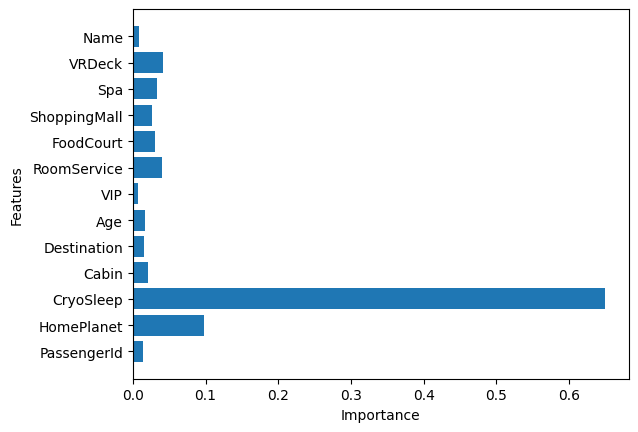

In [84]:
plt.barh(X.columns,model.feature_importances_)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [85]:
train_data.head()

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,1,0,149,2,39.0,0,0.0,0.0,0.0,0.0,0.0,False
1,0,0,2184,2,24.0,0,109.0,9.0,25.0,549.0,44.0,True
2,1,0,1,2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False
3,1,0,1,2,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False
4,0,0,2186,2,16.0,0,303.0,70.0,151.0,565.0,2.0,True


In [86]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth' :[3,5,7],
    'learning_rate': [0.001,0.1],
    'n_estimators':[100,200]
}

grid = GridSearchCV(model,param_grid,cv = 5)
grid.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=0.1, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=5,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.001, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200]})

In [87]:
grid_predictions = grid.predict(X_test)
print("Accuracy",accuracy_score(y_test,grid_predictions))

Accuracy 0.7872340425531915
